<a href="https://colab.research.google.com/github/yrhutu21/Computer_Vision/blob/main/Image_Computer_Vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_digits

In [2]:
dt = load_digits(n_class=3)


In [3]:
images = dt.images

In [4]:
Y = dt.target

In [5]:
images[-2]

array([[ 0.,  0., 15., 13.,  1.,  0.,  0.,  0.],
       [ 0.,  0., 14., 14.,  4.,  0.,  0.,  0.],
       [ 0.,  0.,  1.,  4., 12.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  6., 12.,  0.,  0.,  0.],
       [ 0.,  0.,  0., 11., 10.,  0.,  0.,  0.],
       [ 0.,  0.,  1., 16.,  8.,  6.,  5.,  0.],
       [ 0.,  0., 13., 16., 16., 16., 14.,  0.],
       [ 0.,  0., 10., 13., 10.,  6.,  2.,  0.]])

In [6]:
Y[-2] #label of 2nd last img

np.int64(2)

In [7]:
images[0].reshape(1, 64)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
        15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
        12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
         0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
        10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

In [8]:
images.shape

(537, 8, 8)

In [9]:
X = images.reshape(-1,64)

In [10]:
X.shape

(537, 64)

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim

In [12]:
X = torch.FloatTensor(X)
Y = torch.LongTensor(Y)

In [35]:
model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 3),
)

In [ ]:
# model(X)

In [ ]:
# nn.NLLLoss()

In [14]:
lossfn = nn.CrossEntropyLoss()

In [15]:
opt = optim.Adam(model.parameters(), lr=0.01)

Training

In [49]:
model.train()
for _ in range(200):
    opt.zero_grad()
    Yp = model(X)
    loss = lossfn(Yp, Y)
    loss.backward()
    opt.step()
    print(loss)

tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.6464, grad_fn=<NllLossBackward0>)
tensor(1.64

Using Batches

In [64]:
from torch.utils.data import DataLoader
import pandas as pd

In [65]:
df = pd.DataFrame(X)

In [66]:
df['Y'] = Y

In [67]:
data = torch.tensor(df.to_numpy())

In [68]:
lossfn = nn.CrossEntropyLoss()
batchSgd = optim.SGD(model.parameters(), lr=0.01)

In [69]:
batches = DataLoader(data, batch_size=10, shuffle=True)

In [70]:
model(X)

tensor([[ 0.3119,  0.2397,  0.0243],
        [ 2.2769, -1.2581,  0.5834],
        [ 1.0846,  0.5697,  0.8023],
        ...,
        [ 1.0819, -0.2569,  0.9535],
        [ 1.1656, -0.2203,  1.0184],
        [ 0.5422,  0.2838,  0.3666]], grad_fn=<AddmmBackward0>)

In [17]:
#pip install opencv-python

In [71]:
import cv2

In [72]:
ar = cv2.imread('one_num.jpg')

In [73]:
ar.shape

(1390, 1300, 3)

In [74]:
grar = cv2.cvtColor(ar, cv2.COLOR_BGR2GRAY)

In [75]:
rszar = cv2.resize(grar, (8, 8))

In [76]:
far = rszar.reshape(1, 64)

In [77]:
far

array([[255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255, 255,  83,
        255, 255, 255, 255, 255, 255, 168, 148, 255, 255, 255, 255, 255,
        255, 255, 101, 255, 255, 255, 255, 255, 255, 255, 204, 255, 255,
        255, 255, 255, 255, 255,  61, 255, 255, 255, 255, 255, 255, 255,
        242, 255, 255, 255,   2,   2,   2,   2,   2,   2,   2,   2]],
      dtype=uint8)

In [78]:
fimg = torch.FloatTensor(far)

In [79]:
model(fimg)

tensor([[12.9408, 12.2296,  5.4370]], grad_fn=<AddmmBackward0>)

In [80]:
sfx = torch.softmax(model(fimg), dim=1)

In [81]:
torch.argmax(sfx, dim=1)

tensor([0])

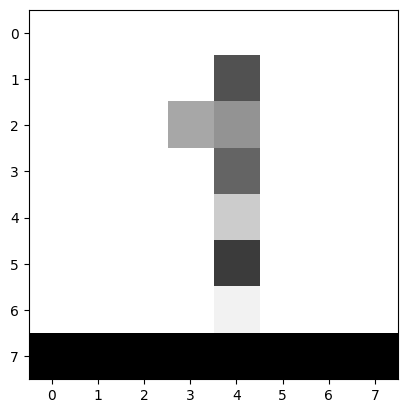

In [82]:
import matplotlib.pyplot as plt
plt.imshow(rszar, cmap='gray')
plt.show()